# Exploratory Data Analysis
It’s a technique of exploring the data to get better understanding of it.

Gain insights by plotting different kinds of graphs using Python libraries, Seaborn, and Matplotlib.

# Heart attack analysis

We have data on patients seen by a cardiologist. The main goal of this notebook is to build a machine learning model, that will be able to predict the risk of a heart attack based on a patient's health condition.

Here we have the description of the features:

age - age in years

sex - sex (0 = female; 1 = male)

cp - chest pain type (1 = typical angina; 2 = atypical angina; 3 = non-anginal pain; 0 = asymptomatic)

trtbps - resting blood pressure (in mm Hg on admission to the hospital)

chol - serum cholestoral in mg/dl

fbs - fasting blood sugar > 120 mg/dl (0 = false; 1 = true)

restecg - resting electrocardiographic results (0 = normal; 1 = hypertrophy; 2 = having ST-T wave abnormality)

thalachh - maximum heart rate achieved

exng - exercise induced angina (0 = no; 1 = yes)

oldpeak - ST depression induced by exercise relative to rest

slp - the slope of the peak exercise ST segment (0 = downsloping; 1 = flat; 2 = upsloping)

caa - number of major vessels (0-4) colored by flourosopy

thall - thallium stress test (1 = fixed defect; 2 = reversable defect; 3 = normal)

output - 0 = less chance of heart attack; 1 = more chance of heart attack

# Import libraries

In [1]:
# Import the library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#read the dataset
df=pd.read_csv('heart.csv')


## Basic EDA

In [3]:
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.tail()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
df.columns

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output'],
      dtype='object')

1.The dataset includes information about 303 patients.

2.There are 13 features. Even though all of them are numeric type, only 5 are really numerical, the rest are categorical.

            categorical features : sex, cp, fbs, restecg, exng, slp, caa, thall
   
            numerical features : age, trtbps, chol, thalachh, oldpeak

3.The target is output. 0 is low risk patient, 1 is high risk patient.

4.There are no missing values.

# (Advanced EDA) Data Cleaning / Data Preprocessing

In [7]:
# Check for Null Values
df.isnull().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

## Check for duplicate

In [8]:
df[df.duplicated()]

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


There is one duplicate we observed and delete it

In [9]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df.shape

(302, 14)

In [10]:
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# Outlier
Outlier is an observation in a given dataset that lies far from the rest of the observations.
An outlier may occur due to the variability in the data, or due to experimental error/human error.



<AxesSubplot:>

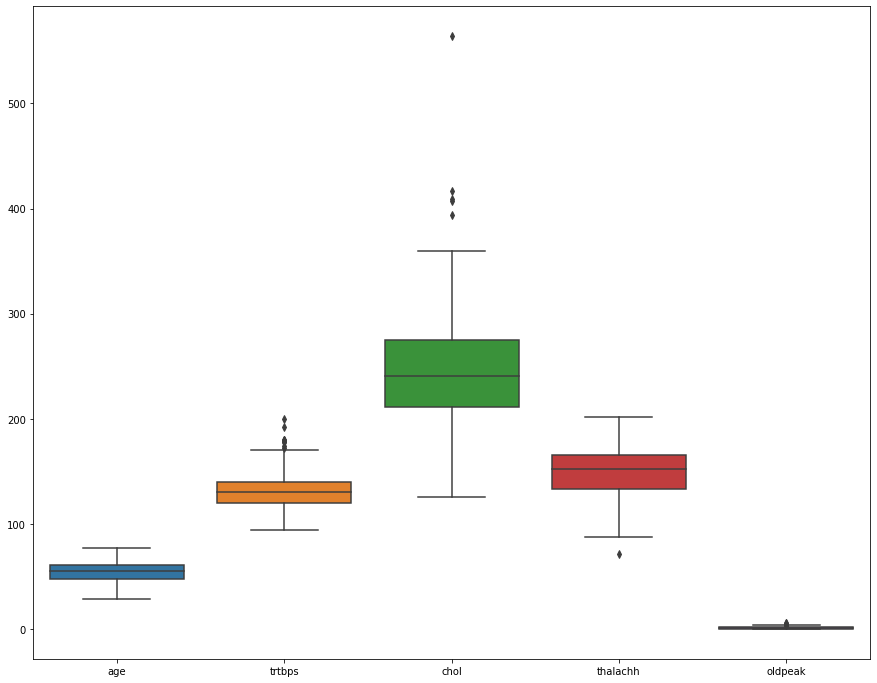

In [11]:
# Checking for the presence of outliers in numeric cols ('age','trtbps','chol','thalachh','oldpeak')

plt.figure(figsize=(15,12))
# df.boxplot(column=['age','trtbps','chol','thalachh','oldpeak'])  
sns.boxplot(data=df[['age','trtbps','chol','thalachh','oldpeak']])

In [12]:
#Finding values of outliers(IQR method)
# 1. Sort the dataset in ascending order,
# 2 calculate the 1st and 3rd quartiles(Q1, Q3)
# 3  compute IQR=Q3-Q1,
# 4 compute lower bound = (Q1–1.5*IQR), upper bound = (Q3+1.5*IQR),
# 5 loop through the values of the dataset and check for those who fall below the lower bound 
#and above the upper bound and mark them as outliers


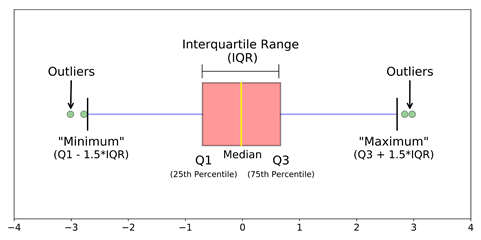

No outliers are present in age attribute but there are outliers in trtbps, chol, thalachh and oldpeak attributes. 
So we need to get the exact values of outliers using IQR method.

In [13]:

def detect_outliers_iqr(data):
    outlier_list = []
    data = sorted(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    # print("The Val of Q1 and Q2",q1, q3)
    IQR = q3-q1
    lwr_bound = q1-(1.5*IQR)
    upr_bound = q3+(1.5*IQR)
    # print("The lower & Upper Bound",lwr_bound, upr_bound)
    
    for i in data: 
        if (i<lwr_bound or i>upr_bound):
            outlier_list.append(i)
    return outlier_list 



for i in ['age','trtbps','chol','thalachh','oldpeak']:
    outliers = detect_outliers_iqr(df[i])
    print("Outliers in",i,"attribute :", outliers)

Outliers in age attribute : []
Outliers in trtbps attribute : [172, 174, 178, 178, 180, 180, 180, 192, 200]
Outliers in chol attribute : [394, 407, 409, 417, 564]
Outliers in thalachh attribute : [71]
Outliers in oldpeak attribute : [4.2, 4.2, 4.4, 5.6, 6.2]


## Observation
No outliers in age attribute

Outliers in trtbps attribute : 172, 174, 178, 178, 180, 180, 180, 192, 200

Outliers in chol attribute : 394, 407, 409, 417, 564

Outliers in thalachh attribute : 71

Outliers in oldpeak attribute : 4.2, 4.2, 4.4, 5.6, 6.2


Now we need to handle these outlier using Quantile based flooring and capping method.

In [14]:
# Handling outliers using Quantile based flooring and capping method.
#the outlier is capped at a certain value above the 90th percentile value or floored at a factor below the 10th percentile value
# Computing 10th, 90th percentiles and replacing the outliers

def handle_outliers(data):

    tenth_percentile = np.percentile(data, 10)
    ninetieth_percentile = np.percentile(data, 90)
    
    print('10th,tenth_percentile',tenth_percentile)
    print('90th,tenth_percentile',ninetieth_percentile)
    
    b = np.where(data<tenth_percentile, tenth_percentile, data)

    b1 = np.where(b>ninetieth_percentile, ninetieth_percentile, b)
    return b1
    
    
for i in ['trtbps','chol','thalachh','oldpeak']:
    df[i]=handle_outliers(df[i])
    print(df[i])



10th,tenth_percentile 110.0
90th,tenth_percentile 152.0
0      145.0
1      130.0
2      130.0
3      120.0
4      120.0
       ...  
297    140.0
298    110.0
299    144.0
300    130.0
301    130.0
Name: trtbps, Length: 302, dtype: float64
10th,tenth_percentile 188.4
90th,tenth_percentile 308.90000000000003
0      233.0
1      250.0
2      204.0
3      236.0
4      308.9
       ...  
297    241.0
298    264.0
299    193.0
300    188.4
301    236.0
Name: chol, Length: 302, dtype: float64
10th,tenth_percentile 116.0
90th,tenth_percentile 176.80000000000007
0      150.0
1      176.8
2      172.0
3      176.8
4      163.0
       ...  
297    123.0
298    132.0
299    141.0
300    116.0
301    174.0
Name: thalachh, Length: 302, dtype: float64
10th,tenth_percentile 0.0
90th,tenth_percentile 2.8
0      2.3
1      2.8
2      1.4
3      0.8
4      0.6
      ... 
297    0.2
298    1.2
299    2.8
300    1.2
301    0.0
Name: oldpeak, Length: 302, dtype: float64


<AxesSubplot:>

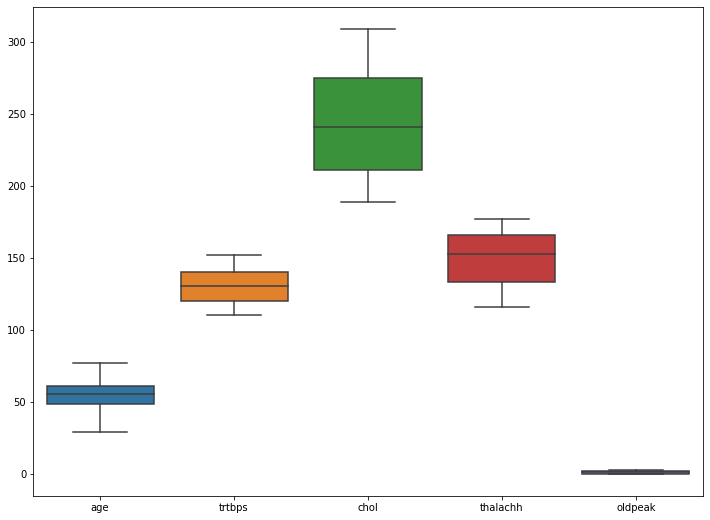

In [15]:
# verifying again with boxplot

plt.figure(figsize=(12,9))
# df.boxplot(column=['age','trtbps','chol','thalachh','oldpeak']);
sns.boxplot(data=df[['age','trtbps','chol','thalachh','oldpeak']])

# Visualization

In this section, we will get an idea about our patients by considering all the features separately.

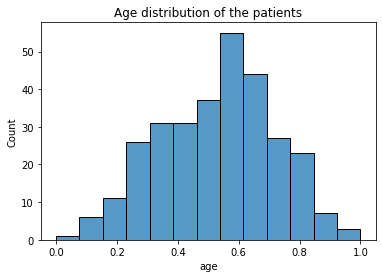

<Figure size 432x288 with 0 Axes>

In [44]:
#Age
sns.histplot(df.age) 
plt.title('Age distribution of the patients')
plt.show()
plt.savefig('age1.png')

The dataset contains information about older patients, which is to be expected. The majority of the patients are older than 40.  The peak is at 57-58 years old.

In [17]:
#Gender
df.sex.value_counts().to_frame()

,sex
1,206
0,96


/usr/local/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='sex', ylabel='count'>

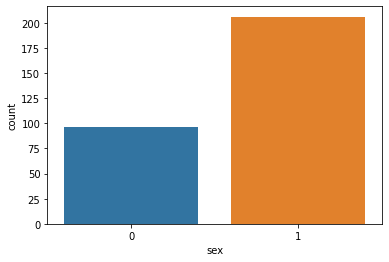

In [18]:
#countplot is used to show the count of each observation
sns.countplot('sex',data=df)

<AxesSubplot:xlabel='sex', ylabel='cp'>

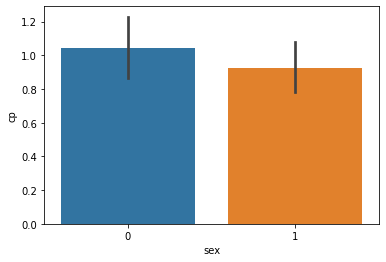

In [19]:
sns.barplot(x='sex',y='cp',data=df)

0=Female

1=Male

We have almost 2 times more males than females

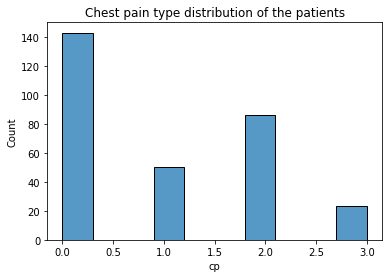

In [20]:
#Chest pain type
sns.histplot(df.cp)
plt.title('Chest pain type distribution of the patients')
plt.show()

1 = typical angina; 2 = atypical angina; 3 = non-anginal pain; 0 = asymptomatic

Almost a half of the patients have no pain in the chest

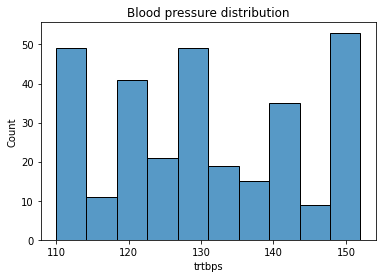

In [21]:
#Resting blood pressure
sns.histplot(df.trtbps)
plt.title('Blood pressure distribution')
plt.show()

According to the European Society of Cardiology, the following classification for blood pressure is applied:

        Category           Blood pressure

        Optimal	              < 120

        Normal	              120–129

        High normal	         130–139

        Grade 1 hypertension	140–159

        Grade 2 hypertension	160–179

        Grade 3 hypertension	 ≥ 180

In our dataset, the resting blood pressure distribution has a peak at a value of approx. 150

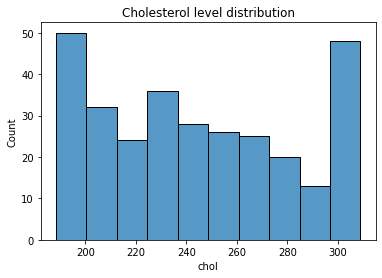

In [22]:
#Cholesterol
sns.histplot(df.chol)
plt.title('Cholesterol level distribution')
plt.show()

In [23]:
#Fasting blood sugar
df.fbs.value_counts().to_frame()   # when var is categorical then you can use value_counts()

,fbs
0,257
1,45


Reminder: 0 means less or equal to 120 mg/dl (which is good), 1 means higher than 120 mg/dl.

The majority of the patients don't have serious sugar problems.

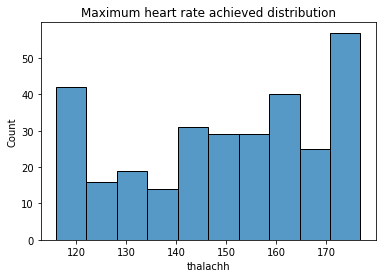

In [24]:
#Maximum heart rate achieved
sns.histplot(df.thalachh)
plt.title('Maximum heart rate achieved distribution')
plt.show()

In our dataset, highest value for thalachh is apprx. 170-180

The peak is at 0.   
0-1 is normal.

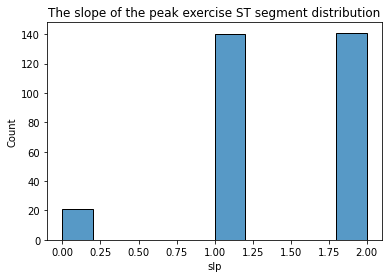

In [25]:
#The slope of the peak exercise ST segment
sns.histplot(df.slp)
plt.title('The slope of the peak exercise ST segment distribution')
plt.show()

0 = downsloping; 1 = flat; 2 = upsloping   
The slope of peak exercise ST segment (slp) is mostly flat and upsloping.

In [26]:
#The chance of heart attack
df.output.value_counts().to_frame()

,output
1,164
0,138


 0 = less chance of heart attack; 1 = more chance of heart attack


The conclusion is that people with good health condition has a lower chance to a heart attack.

Text(0.5, 1.0, 'Correlation map')

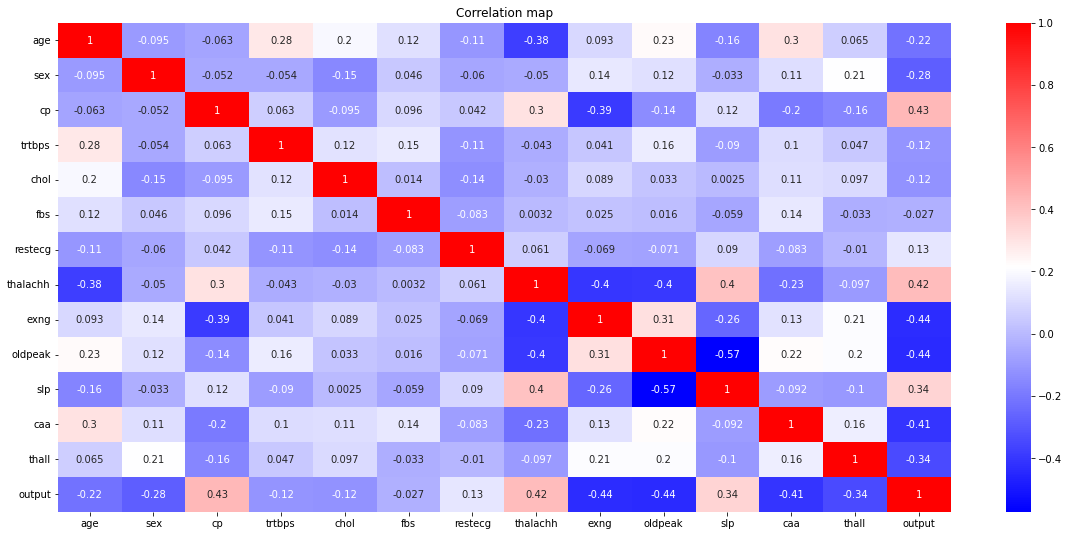

In [27]:
#Finding the correlation
plt.figure(figsize=(20,9));
sns.heatmap(df.corr(),annot=True,cmap='bwr');  
plt.title("Correlation map")

From the above heatmap we can observe that the features 'cp', 'thalachh', 'exng', 'oldpeak' and 'caa' are highly correlated to output (target variable).

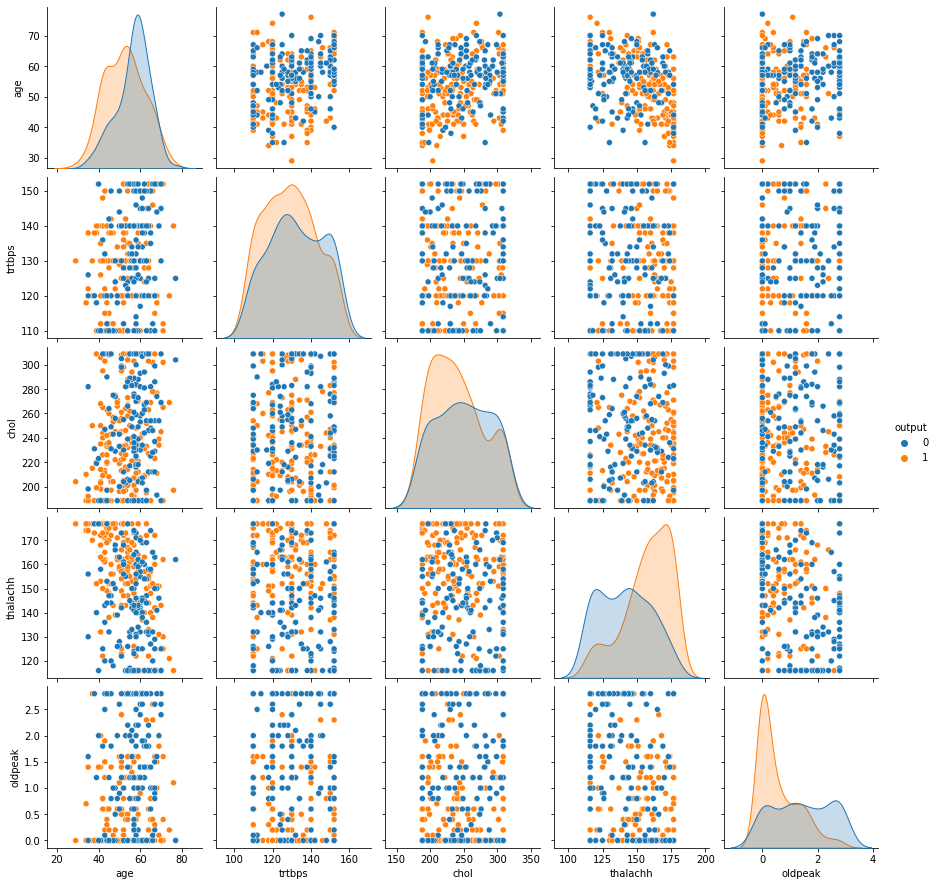

In [28]:
# pairplot for numeric columns, to plot pairwise relationships between variables within a dataset
# use to check whether data is linearly separable or non linearly seperable
sns.pairplot(df[['age','trtbps','chol','thalachh','oldpeak','output']],hue='output')   # name of dependent variable

From the above pair plot we can conclude that our dataset is not linearly separable.




# Conclusion  (Visualization):

1.The majority of the patients are older than 40.

2.In the dataset there are 2 times more males than females.

3.54.3% of the patients have a high risk of heart attack, 45.7% - low risk of a heart attack.

4.Age distribution of patients from the high-risk group has a peak at 57-58 ages.

5.The major factors influencing heart attacks are: Chest pain, Maximum heart rate achieved, Exercise induced angina, ST depression induced by exercise relative to rest and Number of major vessels

# Feature Scaling

In [29]:
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,1
1,37,1,2,130.0,250.0,0,1,176.8,0,2.8,0,0,2,1
2,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,1
3,56,1,1,120.0,236.0,0,1,176.8,0,0.8,2,0,2,1
4,57,0,0,120.0,308.9,0,1,163.0,1,0.6,2,0,2,1


In [30]:
from sklearn.preprocessing import MinMaxScaler

scale = MinMaxScaler()
df[['age','trtbps','chol','thalachh','oldpeak']]=scale.fit_transform(df[['age','trtbps','chol','thalachh','oldpeak']])

In [31]:
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,0.708333,1,3,0.833333,0.370124,1,0,0.559211,0,0.821429,0,0,1,1
1,0.166667,1,2,0.476190,0.511203,0,1,1.000000,0,1.000000,0,0,2,1
2,0.250000,0,1,0.476190,0.129461,0,0,0.921053,0,0.500000,2,0,2,1
3,0.562500,1,1,0.238095,0.395021,0,1,1.000000,0,0.285714,2,0,2,1
4,0.583333,0,0,0.238095,1.000000,0,1,0.773026,1,0.214286,2,0,2,1


# Data Preparation

In [32]:
from sklearn.model_selection import train_test_split # Import train_test_split function

In [33]:
#split dataset in features and target variable

feature_cols = ['age', 'sex', 'cp', 'trtbps', 'chol', 'restecg','fbs','thalachh','exng', 'oldpeak', 'slp', 'caa', 'thall']
X = df[feature_cols] # Features
y = df.output # Target variable

So, we are preparing the data by spliting the features as X and Y ,Here X defines the feature columns and Y defines the target variable

In [34]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) # 80% training and 20% test

Here splitting the dataset into train set and test set with the size of 80% and 20%

## Classification models

In [35]:
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.ensemble import RandomForestClassifier # Random Forest
from sklearn import svm # SVM
from sklearn.linear_model import LogisticRegression # Logistic Regression
from sklearn.naive_bayes import GaussianNB #Naive Byes
from xgboost import XGBClassifier #Extreme Gradient Boost
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

In [36]:
clf = DecisionTreeClassifier(criterion="entropy", max_depth=10)

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

# Accuracy
dt_accuracy=round(metrics.accuracy_score(y_test, y_pred)*100,2)
print("\nAccuracy:",dt_accuracy,'%')


print(metrics.classification_report(y_test, y_pred))


Accuracy: 67.21 %
              precision    recall  f1-score   support

           0       0.72      0.64      0.68        33
           1       0.62      0.71      0.67        28

    accuracy                           0.67        61
   macro avg       0.67      0.68      0.67        61
weighted avg       0.68      0.67      0.67        61



In [37]:
# SVM classifier

clf = svm.SVC() # Create SVM classifier

# Train the dataset
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

# Accuracy
svm_accuracy=round(metrics.accuracy_score(y_test, y_pred)*100,2)
print("\nAccuracy:",dt_accuracy,'%')


print(metrics.classification_report(y_test, y_pred))


Accuracy: 67.21 %
              precision    recall  f1-score   support

           0       0.77      0.70      0.73        33
           1       0.68      0.75      0.71        28

    accuracy                           0.72        61
   macro avg       0.72      0.72      0.72        61
weighted avg       0.73      0.72      0.72        61



In [38]:
# Logistic Regression

clf = LogisticRegression() 

# Train the dataset
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

# Accuracy
lr_accuracy=round(metrics.accuracy_score(y_test, y_pred)*100,2)
print("\nAccuracy:",dt_accuracy,'%')


print(metrics.classification_report(y_test, y_pred))



Accuracy: 67.21 %
              precision    recall  f1-score   support

           0       0.74      0.70      0.72        33
           1       0.67      0.71      0.69        28

    accuracy                           0.70        61
   macro avg       0.70      0.71      0.70        61
weighted avg       0.71      0.70      0.71        61



In [39]:
# Random Forest

clf=RandomForestClassifier(n_estimators=100,criterion =  "entropy")

# Train the dataset
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

# Accuracy
rf_accuracy=round(metrics.accuracy_score(y_test, y_pred)*100,2)
print("\nAccuracy:",dt_accuracy,'%')


print(metrics.classification_report(y_test, y_pred))



Accuracy: 67.21 %
              precision    recall  f1-score   support

           0       0.73      0.67      0.70        33
           1       0.65      0.71      0.68        28

    accuracy                           0.69        61
   macro avg       0.69      0.69      0.69        61
weighted avg       0.69      0.69      0.69        61



In [40]:
# XGBoost

clf=XGBClassifier(n_estimators=30)

# Train the dataset
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

# Accuracy
xgb_accuracy=round(metrics.accuracy_score(y_test, y_pred)*100,2)
print("\nAccuracy:",dt_accuracy,'%')


print(metrics.classification_report(y_test, y_pred))




Accuracy: 67.21 %
              precision    recall  f1-score   support

           0       0.70      0.70      0.70        33
           1       0.64      0.64      0.64        28

    accuracy                           0.67        61
   macro avg       0.67      0.67      0.67        61
weighted avg       0.67      0.67      0.67        61



In [41]:
model_ev = pd.DataFrame({'Model':['LR','RF','XGB','DT','SVM'],
                    'Accuracy %':[lr_accuracy,rf_accuracy,xgb_accuracy,dt_accuracy,svm_accuracy]
                                })

model_ev.sort_values(by='Accuracy %')
model_ev

,Model,Accuracy %
0,LR,70.49
1,RF,68.85
2,XGB,67.21
3,DT,67.21
4,SVM,72.13


<AxesSubplot:xlabel='Model', ylabel='Accuracy %'>

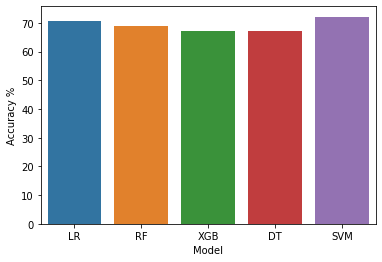

In [42]:
sns.barplot(x='Model',y='Accuracy %',data=model_ev)